# Stellar Mergers: A Binary Population Synthesis Approach

This notebook is a tutorial introducing you to binary population synthesis (BPS), binary stellar evolution, and how to run your own BPS simulations using `COMPAS`, an open source code for simulation populations of binary star systems.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import subprocess
import pandas as pd
from IPython.display import Image, display

pd.set_option('display.max_columns', None)

## Binary Population Synthesis

### Massive Stars

Observational surveys have found that the majority of massive stars ($M>8 \ M_\odot$) are born in binaries or higher-order multiples, meaning that two or more stars are gravitationally bound and orbit a common center of mass (Sana et al. 2012). This is significant because now when studying the massive stars, we need to consider this binarity and the implications it has on the evolution of the stars because as a result of these companions, stars in binaries don't evolve in isolation--binary interactions impact evolution. Over the course of their lifetime, binary stars can:
- Transfer mass to their companion (mass transfer / Roche lobe overflow)
- Undergo runaway mass transfer that can lead to a stellar merger (common envelope)
- Become unbound after a supernova kick
- Remain bound and form a double compact object (binary black hole, binary neutron star, black hole-neutron star pair) which we can detect via gravitational waves when they merge

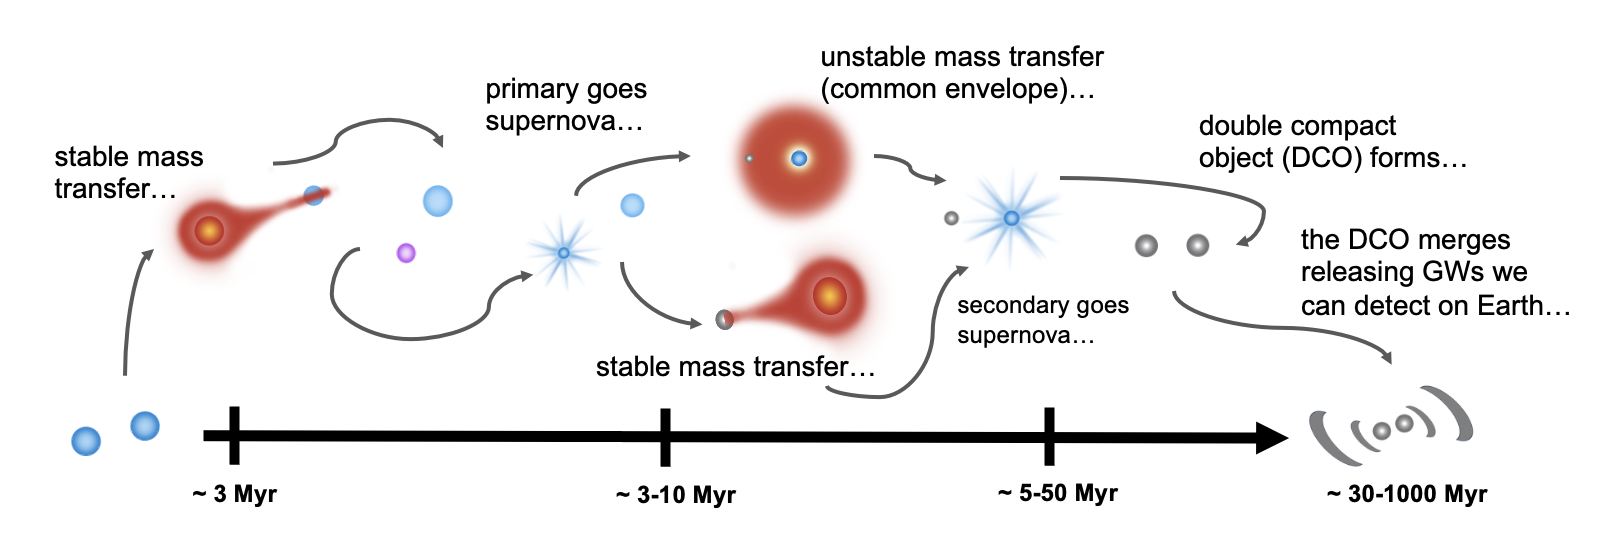

In [2]:
display(Image(filename='figs/isolated_binary_evolution.png', width=800))

### BPS Codes

We can predict the statistical properties of binary star populations via binary population synthesis. Rather than studying individual massive binaries, we can simulate a population, analyze population trends, and compare them to observations from surveys. Binary population synthesis simulations do the following:
1. Draw initial parameters from distributions (masses, orbital period, mass ratios, metallicity) motivated by observations
2. Evolve each binary from the zero-age main sequence (ZAMS, aka birth) to its final state using rapid analytic stellar evolution prescriptions
3. Record outcomes: stellar merger, unbound by SNe, compact object binaries, etc
4. Collect statistics of the full population regarding outcomes + binary properties
5. (Post processing) Convolve these simulations with star formation histories to predict observable rates

We use these codes because detailed stellar evolution codes such as `MESA` can take days to evolve a single system. BPS codes can evolve a single binary in milliseconds, allowing us to explore large and multidimensional parameter spaces. However, the trade off is that BPS codes use simply and analytic fits. The strength is to use BPS results to do population inference.

### Stellar Mergers

A lot of BPS codes have been used to forward model the gravitational wave observations we have been collecting from the LIGO-Virgo-KAGRA (LVK) collaboration since 2016. This focus on the rare outcome of binary stellar evolution that results in binary black holes (BBHs), binary neutron stars (BNSs), and black hole-neutron star (BHNS) pairs, that are close enough to merge within the age of the universe. However, we want to use BPS codes to study stellar mergers: mergers of two massive stars during runaway mass transfer (common envelope phase). Specifically, we are interested in:
- Merger rates across cosmic time: predicting when and how often stellar mergers occur as a function of redshift, which depends on star formation rates and metallicitiy. 
- Which stars merge during common envelope: analyzing which binary configurations, e.g. masses, mass ratios, stellar types, merge during the common envelope phase

The common envelope phase is a poorly understand highly computationally complex physical processes. In this phase, one component in our binary, the donor, overflows their Roche lobe (material begins spilling out of their gravitational sphere of influence), allowing mass to be 'consumed' by their companion. A common envelope forms when this transfer of mass is unstable and begins a runaway process--the orbit shrinks as a consequence of the donor losing mass, causing the Roche lobe to shrink, and for more mass to be transfered! This dynamically unstable mass transfer overwhelms the receiving star, and the donor star's envelope keeps puffing up until it engulfs both stars. The two objects continue their orbital motion within this shared envelope, but drag forces drives further decrease of their orbital separation. At this point, we have two outcomes: a surviving closer binary, or a stellar merger. If the loss of orbital energy heats up and expands the envelope, the envelope can be expelled if it overcomes the binding energy. If this doesn't happen, the stars merge.

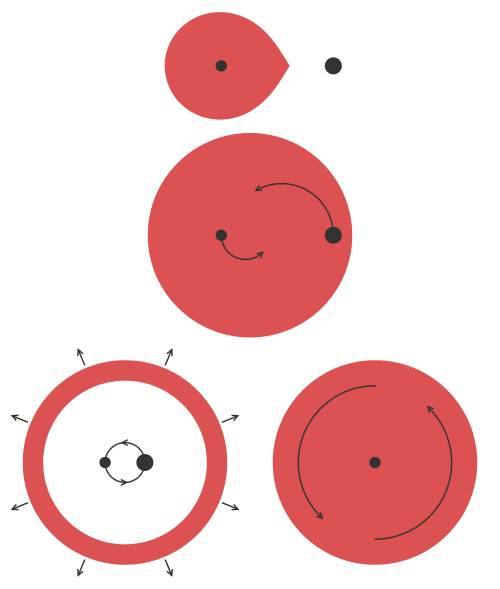

In [3]:
display(Image(filename='figs/common_envelope.png', width=400))

## `COMPAS`

`COMPAS` (Compact Object Mergers: Population Astrophysics and Statistics) is a publicly available rapid binary population synthesis code we will use to create and evolve our populations of binary stars (https://compas.science). Before continuing this tutorial that will get you familiar with using `COMPAS` you must first install `COMPAS` on your machine. The instructions for installing `COMPAS` can be found here: https://compas.readthedocs.io/en/latest/pages/Getting%20started/getting-started.html.

Once you have the executable installed you should be able to run this and get the following

```bash
# print COMPAS version
./COMPAS -v
```
```bash

COMPAS v03.27.03 (gsl v2.7.1, boost v1.83.0, HDF5 v1.10.10)
Compact Object Mergers: Population Astrophysics and Statistics
by Team COMPAS (http://compas.science/index.html)
A binary star simulator

Go to https://compas.readthedocs.io/en/latest/index.html for the online documentation
Check https://compas.readthedocs.io/en/latest/pages/whats-new.html to see what's new in the latest release
```

`COMPAS` works by:
1. Sampling initial conditions/population property distributions specified by the user
2. Evolves stars (mass, radius, stellar type) through each evolutionary phase using analytic formulas
3. Simulates binary interactions such as mass transfer, supernova, common envelopes, etc. via parameterized prescriptions which the user can specify (e.g. changing the knob off mass transfer efficiency)
4. Records outcomes of binaries after binary interactions

After evolving the population, `COMPAS` will spit out the results in HDF5 formats (file format to store LARGE amountso of data). `COMPAS` produces `COMPAS_Output.h5` which has the following data groups:
- `BSE_System_Parameters`: data group containing initial + final states of binaries
- `BSE_Common_Envelopes`: details of each binary's common envelope event(s)
- `BSE_RLOF`: details of each binary's mass transfer event(s) (everytime a companion overflows its Roche lobe)
- `BSE_Supernovae`: details of each binary's supernova event(s)
- `BSE_Double_Compact_Objects`: details for binary's ending as BBH, BNS, BHNS
<!-- - `BSE_Detailed_Output`: if enabled, you get this output for specific time steps -->

### Running a `COMPAS` Simulation

The easiest and most flexible way to run `COMPAS` with Python is to do so with a `YAML` config file that gets passed to the `compas_run_submit` command to run a `COMPAS` simulation with all your user-specified parameters. In this folder the `compas_tutorial_config.yaml` mirrors the `COMPAS` `compasConfigDefault.yaml` file. Usually this file is all commented out to run `COMPAS` with default values. In this tutorial I change the following:

```yaml
# ./tutorial/compasConfigDefault.yaml
booleanChoices:
    ...
    --detailed-output: False
    ...

numericalChoices:
    ...
    --number-of-systems: 10000
    --metallicity: 0.014200  
    --mass-transfer-fa: 0.50  
    --common-envelope-alpha: 1.00
    --random-seed: 42  
    ...
stringChoices:
    ...
    --mode: 'BSE'  
    --logfile-type: 'HDF5' 
    ...
```

Now, we can run `COMPAS` with this configuration file.

In [4]:
! compas_run_submit compas_tutorial_config.yaml

python_version = 3
compas_executable_override /Users/tsdevictor/Software/COMPAS/src/COMPAS
grid_filename None
/Users/tsdevictor/Software/COMPAS/src/COMPAS --detailed-output False --number-of-systems 1000 --metallicity 0.0142 --random-seed 42 --mass-transfer-fa 0.5 --common-envelope-alpha 1.0 --mode BSE --logfile-type HDF5 --output-path /Users/tsdevictor/Documents/menon-lab/stellar_mergers/tutorial

COMPAS v03.29.03 (gsl v2.8, boost v1.90.0, HDF5 v2.1.1)
Compact Object Mergers: Population Astrophysics and Statistics
by Team COMPAS (http://compas.science/index.html)
A binary star simulator

Go to https://compas.readthedocs.io/en/latest/index.html for the online documentation
Check https://compas.readthedocs.io/en/latest/pages/whats-new.html to see what's new in the latest release

Start generating binaries at Thu Apr  9 01:50:11 2026

0: Stars merged: (Main_Sequence_>_0.7 -> Early_Asymptotic_Giant_Branch) + (Main_Sequence_<=_0.7 -> Main_Sequence_<=_0.7)
1: Allowed time exceeded: (Main_Se

We evolved a population of $N=1,000$ binaries in $\sim 16$ seconds! Each numbered line tells you the final evolutionary state of the binary, the initial stellar type of the binary components, and the final stellar type of the binary components. I see some mergers!

### Key Parameters for this Project

The parameters we will be changing/exploring their impact are the following:
- `--number-of-systems`: number of binaries to evolve
- `--metallicity`: metallicity, default is solar (Z=0.0142)
- `--common-envelope-alpha`: common envelope energy efficiency, default is $\alpha_\text{CE}=1$
- `--mass-transfer-fa`: mass transfer accretion fraction, default is $\beta=0.5$
- `--random-seed`: seed number for simulation reproducability

### `COMPAS` Outputs

In the `COMPAS_outputs` folder you will find the simulation data. There is a file `RunDetails` with the simulation run details and the `COMPAS_Output.h5` which has our simulation data. First let's take a look at the data groups in this h5 file.

In [5]:
output_path = 'COMPAS_Output/COMPAS_Output.h5'
with h5py.File(output_path, 'r') as f:
    # List all groups
    print("Data Groups: %s" % f.keys())

Data Groups: <KeysViewHDF5 ['BSE_Common_Envelopes', 'BSE_Double_Compact_Objects', 'BSE_RLOF', 'BSE_Supernovae', 'BSE_System_Parameters', 'Run_Details']>


Great! Many groups. Now let's explore a couple with this helper function. Here we can see exactly what is logged/recorded in each data group for our simulation. We will look at `BSE_System_Parameters`, which holds our initial binaries data (and some summary data on their evolution + final state), and `BSE_Common_Envelopes`, which holds the data for each CE that happens for a binary (note some binaries undergo many CE events given they survive each prior CE event).

In [6]:
def load_compas_group(h5_path, group_name):
    """
    Load a COMPAS HDF5 output group into a dictionary.
    
    Parameters:
    -----------
    h5_path : str
        Path to COMPAS_Output.h5
    group_name : str
        Name of the HDF5 group (e.g., 'BSE_System_Parameters')
    
    Returns:
    --------
    data : dict
        Dictionary mapping column names to numpy arrays
    """
    data = {}
    with h5py.File(h5_path, 'r') as f:
        group = f[group_name]
        for col in group.keys():
            data[col] = group[col][:]
    return data

sys_params_df = pd.DataFrame(load_compas_group(output_path, 'BSE_System_Parameters'))
sys_params_df.head(10)

,CH_on_MS(1),CH_on_MS(2),Eccentricity@ZAMS,Equilibrated_At_Birth,Error,Evolution_Status,Mass@ZAMS(1),Mass@ZAMS(2),Merger,Merger_At_Birth,Metallicity@ZAMS(1),Metallicity@ZAMS(2),Omega@ZAMS(1),Omega@ZAMS(2),PO_CE_Alpha,PO_CE_Formalism,PO_LBV_Factor,PO_Sigma_Kick_CCSN_BH,PO_Sigma_Kick_CCSN_NS,PO_Sigma_Kick_ECSN,PO_Sigma_Kick_USSN,PO_WR_Factor,Record_Type,SEED,SN_Kick_Magnitude_Random_Number(1),SN_Kick_Magnitude_Random_Number(2),SemiMajorAxis@ZAMS,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Unbound
0,0,0,0.0,0,0,12,5.416431,0.365624,1,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,42,0.796543,0.950714,1.978083,5,0,1,0,0
1,0,0,0.0,0,43,3,9.884272,7.278885,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,43,0.496861,0.609067,0.179082,11,13,1,1,0
2,0,0,0.0,0,43,15,6.263390,2.504365,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,44,0.432542,0.104796,25.097195,12,11,1,1,0
3,0,0,0.0,0,43,3,8.209055,0.476427,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,45,0.304536,0.549545,39.662997,13,0,1,0,1
4,0,0,0.0,0,43,15,7.763171,3.106212,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,46,0.258047,0.634834,366.109909,12,11,1,1,0
5,0,0,0.0,0,43,14,35.560663,23.082648,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,47,0.851757,0.974483,0.950272,14,14,1,1,0
6,0,0,0.0,0,43,3,7.327586,6.346153,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,48,0.426484,0.891573,2.499422,13,12,1,1,1
7,0,0,0.0,0,43,15,5.141652,2.835602,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,49,0.473737,0.247062,49.968815,11,11,1,1,0
8,0,0,0.0,0,43,14,45.432704,18.814374,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,50,0.129175,0.228083,105.538949,14,14,1,1,0
9,0,0,0.0,0,43,3,8.613415,1.430632,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,51,0.327111,0.044712,135.193485,13,11,1,1,1


In [7]:
ce_df = pd.DataFrame(load_compas_group(output_path, 'BSE_Common_Envelopes'))
print(f"Number of CE events: {ce_df.shape[0]}")
print(f"Number of unique binary systems that had a CE event: {ce_df['SEED'].nunique()}")
ce_df.head(10)

Number of CE events: 459
Number of unique binary systems that had a CE event: 422


,BE_Fixed(1),BE_Fixed(2),BE_Kruckow(1),BE_Kruckow(2),BE_Loveridge(1),BE_Loveridge(2),BE_Loveridge_Winds(1),BE_Loveridge_Winds(2),BE_Nanjing(1),BE_Nanjing(2),Binding_Energy<CE(1),Binding_Energy<CE(2),CE_Event_Counter,Double_Core_CE,Eccentricity<CE,Eccentricity>CE,Immediate_RLOF>CE,Lambda@CE(1),Lambda@CE(2),Lambda_Convective(1),Lambda_Convective(2),Lambda_Fixed(1),Lambda_Fixed(2),Lambda_Kruckow(1),Lambda_Kruckow(2),Lambda_Loveridge(1),Lambda_Loveridge(2),Lambda_Loveridge_Winds(1),Lambda_Loveridge_Winds(2),Lambda_Nanjing(1),Lambda_Nanjing(2),Luminosity<CE(1),Luminosity<CE(2),MT_History,Mass(1)<CE,Mass(1)>CE,Mass(2)<CE,Mass(2)>CE,Mass_Convective_Env(1),Mass_Convective_Env(2),Mass_Env(1),Mass_Env(2),Merger,Optimistic_CE,RLOF(1),RLOF(2),Radius(1)<CE,Radius(1)>CE,Radius(2)<CE,Radius(2)>CE,Record_Type,RocheLobe(1)<CE,RocheLobe(1)>CE,RocheLobe(2)<CE,RocheLobe(2)>CE,SEED,SemiMajorAxis<CE,SemiMajorAxis>CE,SemiMajorAxisStage1>CE,Simultaneous_RLOF,Stellar_Type(1),Stellar_Type(1)<CE,Stellar_Type(2),Stellar_Type(2)<CE,Tau_Circ,Tau_Dynamical<CE(1),Tau_Dynamical<CE(2),Tau_Radial<CE(1),Tau_Radial<CE(2),Tau_Sync(1),Tau_Sync(2),Tau_Thermal<CE(1),Tau_Thermal<CE(2),Teff<CE(1),Teff<CE(2),Time,Zeta_Lobe,Zeta_Star
0,4.307984e+31,1.465026e+49,9.566597e+30,3.891172e+46,4.307984e+30,1.465026e+48,4.307984e+30,1.465026e+48,3.762642e+30,1.465026e+48,2.631717e+47,1.465026e+48,1,0,0.0,0.0,0,1.144936,1.000000,1.216789,1.211233,0.1,0.1,0.450315,37.649993,1.0,1.0,1.0,1.0,1.144936,1.000000,12596.076581,0.019605,6,5.311054,0.000000,0.365624,0.000000,2.220446e-16,0.337921,3.957640,0.000000,1,0,1,0,264.737275,0.000000,0.346292,0.000000,1,262.892047,0.000000,80.265520,0.000000,42,433.247197,0.000000,0.0,0,5,5,0,0,0.0,9.345494e-08,1.685065e-11,0.276038,1.235713e+06,0.0,0.0,1.979230e-04,618.301646,3762.086814,3674.051785,98.720806,26.238545,0.063255
1,0.000000e+00,8.216967e+50,0.000000e+00,2.673226e+48,0.000000e+00,8.216967e+49,0.000000e+00,8.216967e+49,0.000000e+00,2.537386e+50,0.000000e+00,2.416518e+48,1,0,0.0,0.0,0,1.000000,0.831105,0.906687,0.914517,0.1,0.1,748.957830,30.738020,1.0,1.0,1.0,1.0,1.000000,0.323836,0.223016,49241.202572,4,1.315709,1.315709,12.715627,3.188120,0.000000e+00,0.000000,0.000000,9.527507,0,0,0,1,0.003903,0.003903,228.923040,0.469436,1,79.219107,0.972571,218.296044,1.455166,43,379.340589,3.183517,0.0,0,11,11,7,4,0.0,1.062909e-14,4.856634e-08,-1.000000,1.725185e-02,0.0,0.0,1.062909e-14,0.000337,63556.424229,5688.725109,37.121529,16.560896,0.056754
2,2.200934e+50,2.547846e+50,4.406934e+47,3.259769e+48,2.200934e+49,2.547846e+49,2.200934e+49,2.547846e+49,8.792098e+49,2.547846e+49,8.703113e+47,2.547846e+49,1,0,0.0,0.0,0,0.931502,1.000000,0.905983,0.921980,0.1,0.1,49.942520,7.816031,1.0,1.0,1.0,1.0,0.250331,1.000000,5503.861829,803.198623,3,6.153618,1.146533,4.957728,4.957728,0.000000e+00,0.000000,5.007085,0.000000,0,0,1,0,144.236662,0.226665,3.661092,3.661092,1,142.769087,2.739278,129.348904,5.313432,54,358.931799,10.455587,0.0,0,7,3,1,1,0.0,3.491550e-08,1.573057e-10,0.075200,1.194364e+02,0.0,0.0,1.218715e-03,0.262459,4143.874435,16075.998972,64.727500,0.187278,-0.042149
3,0.000000e+00,1.512363e+33,0.000000e+00,3.740141e+31,0.000000e+00,1.512363e+32,0.000000e+00,1.512363e+32,0.000000e+00,1.632551e+32,0.000000e+00,9.156910e+48,2,0,0.0,0.0,0,1.000000,0.926380,0.904257,0.904887,0.1,0.1,379.942727,4.043599,1.0,1.0,1.0,1.0,1.000000,0.926380,0.021842,1558.269514,6,0.731296,1.146533,5.151701,4.957728,0.000000e+00,0.000000,0.000000,4.268813,1,1,0,1,0.010802,0.226665,9.838702,3.661092,1,3.920792,2.739278,9.425378,5.313432,54,17.144941,10.455587,0.0,0,11,11,2,2,0.0,6.564362e-14,6.798317e-10,-1.000000,1.671626e-01,0.0,0.0,6.564362e-14,0.045041,21371.917944,11573.621583,105.801864,11.364605,6.500000
4,0.000000e+00,1.245418e+50,0.000000e+00,1.053976e+48,0.000000e+00,1.245418e+49,0.000000e+00,1.245418e+49,0.000000e+00,7.139779e+49,0.000000e+00,6.951891e+46,1,0,0.0,0.0,0,1.000000,4.296141,0.905953,0.920194,0.1,0.1,544.860612,11.816373,1.0,1.0,1.0,1.0,1.000000,0.1

Go ahead and explore the other data groups, such as `BSE_RLOF`, `BSE_Double_Compact_Objects`, `BSE_Supernovae`...

Now, let's actually look at our data! Let's explore by plotting some CE data, specifically for mergers.

In [8]:
# Tristan visualization

rlof_df = pd.DataFrame(load_compas_group(output_path, 'BSE_RLOF'))
print(f"Number of RLOF events: {rlof_df.shape[0]}")
print(f"Number of unique binary systems that had a RLOF event: {rlof_df['SEED'].nunique()}")
rlof_df.head(10)

Number of RLOF events: 3131
Number of unique binary systems that had a RLOF event: 536


,Beta,CEE>MT,Eccentricity<MT,Eccentricity>MT,MT_Event_Counter,Mass(1)<MT,Mass(1)>MT,Mass(2)<MT,Mass(2)>MT,MassTransferRateDonor,MassTransferTimescale,Merger,RLOF(1)<MT,RLOF(1)>MT,RLOF(2)<MT,RLOF(2)>MT,Radius(1)<MT,Radius(1)>MT,Radius(1)|RL<step,Radius(1)|RL>step,Radius(2)<MT,Radius(2)>MT,Radius(2)|RL<step,Radius(2)|RL>step,Record_Type,SEED,SemiMajorAxis<MT,SemiMajorAxis>MT,Stellar_Type(1)<MT,Stellar_Type(1)>MT,Stellar_Type(2)<MT,Stellar_Type(2)>MT,Time<MT,Time>MT,Zeta_Hurley(1),Zeta_Hurley(2),Zeta_Hurley_He(1),Zeta_Hurley_He(2),Zeta_Soberman(1),Zeta_Soberman(2),Zeta_Soberman_He(1),Zeta_Soberman_He(2)
0,2.957293e-07,1,0.0,0.0,1,5.311054,1.353414,0.365624,0.365624,1.797693e+308,3,1,0,1,0,0,264.737275,264.737275,1.007019e+00,1.548648e+02,0.346292,0.346292,0.004314,0.366662,1,42,433.247197,3.456221,5,5,0,0,98.715854,98.720806,1.706207,-0.293793,1.706207,-0.293793,6.004800e+15,-0.333333,6.004800e+15,-0.333333
1,7.186847e-01,0,0.0,0.0,1,9.811176,2.106102,7.264122,12.801641,7.660041e+02,2,0,0,1,0,0,15.959114,0.347017,1.017573e+00,9.152840e-03,4.314237,5.153896,0.315559,0.060309,1,43,38.706552,159.023633,2,7,1,1,25.557028,25.558047,-0.293793,-0.293793,0.000000,-0.293793,-3.333333e-01,-0.333333,0.000000e+00,-0.333333
2,1.942075e-01,0,0.0,0.0,2,2.086820,1.315709,12.789382,12.939138,1.499533e+04,2,0,0,1,0,0,39.263366,0.003903,1.034244e+00,5.212414e-05,6.268301,6.277933,0.072989,0.030199,1,43,159.601255,360.381298,8,11,1,1,30.164594,30.165489,0.000000,-0.293793,0.000000,-0.293793,0.000000e+00,-0.333333,0.000000e+00,-0.333333
3,6.293700e-09,1,0.0,0.0,3,1.315709,1.315709,12.715627,3.188120,1.797693e+308,3,0,0,0,0,1,0.003903,0.003903,4.926903e-05,4.013125e-03,228.923040,0.469436,1.048682,0.322600,1,43,379.340589,3.183517,11,11,4,7,37.120671,37.121529,0.000000,-0.293793,0.000000,0.000000,0.000000e+00,-0.333333,0.000000e+00,0.000000
4,1.562787e-02,0,0.0,0.0,4,1.315709,1.334838,3.151831,1.927804,5.507965e+02,2,0,0,0,0,1,0.003903,0.003578,3.969087e-03,5.564782e-03,1.516197,0.000014,1.035854,0.000019,1,43,3.209379,1.849619,11,11,8,8,39.125790,39.128070,0.000000,0.000000,1.566951,0.000000,0.000000e+00,0.000000,4.582289e+01,0.000000
5,4.563957e-01,0,0.0,0.0,1,32.566573,10.685430,22.637409,32.623870,3.175758e+04,2,0,0,1,0,0,89.399033,0.975708,1.002645e+00,7.260171e-03,10.199887,10.650542,0.135062,0.047728,1,47,217.069809,467.210269,2,7,1,1,5.442672,5.442740,-0.293793,-0.293793,0.000000,-0.293793,-3.333333e-01,-0.333333,0.000000e+00,-0.333333
6,2.784483e-06,0,0.0,0.0,2,9.283234,9.283292,30.967113,10.065691,8.668183e+04,2,0,0,0,0,1,0.000039,0.000039,2.690551e-07,9.320951e-07,254.169531,0.940484,1.005602,0.021463,1,47,520.661381,113.537255,14,14,2,7,8.414270,8.414344,0.000000,-0.293793,0.000000,0.000000,0.000000e+00,-0.333333,0.000000e+00,0.000000
7,6.286791e-02,0,0.0,0.0,1,7.067181,1.975808,6.330644,6.650728,1.053755e+04,2,0,0,1,0,0,215.361841,1.076787,1.010646e+00,1.723069e-03,5.408661,5.226241,0.026691,0.004821,1,48,548.524453,2229.478229,5,8,1,1,50.844826,50.851340,-0.201501,-0.293793,0.000000,-0.293793,6.955056e-01,-0.333333,0.000000e+00,-0.333333
8,4.482467e-02,0,0.0,0.0,1,7.525935,2.167604,6.528197,6.768383,1.359711e+04,2,0,0,1,0,0,241.570732,1.017575,1.007194e+00,1.553365e-03,4.980309,4.917180,0.022159,0.004475,1,53,612.956623,2290.923155,5,8,1,1,43.780099,43.785894,-0.197006,-0.293793,0.000000,-0.293793,7.129780e-01,-0.333333,0.000000e+00,-0.333333
9,4.597675e-02,1,0.0,0.0,1,6.153618,1.146533,4.957728,4.957728,1.797693e+308,3,0,0,1,0,0,144.236662,0.226665,1.010279e+00,8.274623e-02,3.661092,3.661092,0.028304,0.689026,1,54,358.931799,10.455587,3,7,1,1,64.726146,64.727500,-0.293793,-0.293793,0.000000,-0.293793,-3.333333e-01,-0.333333,0.000000e+00,-0.333333


In [9]:
# Tristan visualization

sup_df = pd.DataFrame(load_compas_group(output_path, 'BSE_Supernovae'))
print(f"Number of supernovae: {sup_df.shape[0]}")
print(f"Number of unique binary systems that had a RLOF event: {sup_df['SEED'].nunique()}")
sup_df.head(10)

Number of supernovae: 577
Number of unique binary systems that had a RLOF event: 389


,Applied_Kick_Magnitude(SN),ComponentSpeed(CP),ComponentSpeed(SN),Drawn_Kick_Magnitude(SN),Eccentricity,Eccentricity<SN,Experienced_RLOF(SN),Fallback_Fraction(SN),Is_Hydrogen_Poor(SN),MT_Donor_Hist(SN),Mass(CP),Mass(SN),Mass_CO_Core@CO(SN),Mass_Core@CO(SN),Mass_He_Core@CO(SN),Mass_Total@CO(SN),Orb_Velocity<SN,Orbital_AM_Vector>SN_X,Orbital_AM_Vector>SN_Y,Orbital_AM_Vector>SN_Z,Radius_Core@CO(SN),Radius_Total@CO(SN),Record_Type,SEED,SN_Kick_Mean_Anomaly(SN),SN_Kick_Phi(SN),SN_Kick_Theta(SN),SN_Orbit_Inclination_Angle,SN_Type(SN),SemiMajorAxis,SemiMajorAxis<SN,Stellar_Type(CP),Stellar_Type(SN),Stellar_Type_Prev(SN),Supernova_State,SystemicSpeed,SystemicVelocityX,SystemicVelocityY,SystemicVelocityZ,Time,Unbound
0,425.296816,257.574483,257.574483,425.296816,4.978022e-01,0.000000e+00,1,0.0,1,b'4-8 ',1.334838,1.207081,1.927804,1.927804,1.927804,1.927804,579.968137,0.539464,-0.485382,0.688028,0.000014,0.000014,1,43,0.838120,5.398120,0.671387,0.812029,16,1.247164,1.849619,11,13,8,2,257.574483,150.145442,-167.382753,125.634289,39.130255,0
1,107.620470,12.532781,107.932147,107.620470,3.674916e+02,0.000000e+00,0,0.0,0,b'NA ',0.476427,1.182872,1.441421,2.279135,2.279135,7.903979,13.444282,0.699992,-0.376392,0.606911,114.690118,469.172205,1,45,4.219031,6.014594,-1.007353,0.918629,1,-23.973811,8841.195546,0,13,5,1,75.154461,36.780285,-9.407799,-64.860596,40.612069,1
2,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1,0.0,1,b'2 ',32.290137,9.283234,6.953343,6.953343,9.283234,9.283234,127.141002,-0.000000,0.000000,1.000000,0.000071,1.064073,1,47,5.715629,2.337743,-0.301617,0.000000,1,490.416555,490.416555,1,14,8,1,0.000000,0.000000,0.000000,0.000000,6.111787,0
3,0.000000,0.000000,0.000000,0.000000,2.220446e-16,0.000000e+00,1,0.0,1,b'2 ',9.283292,9.136705,6.836154,6.836154,9.136705,9.136705,171.570956,0.000000,0.000000,1.000000,0.000071,1.061949,1,47,4.578775,5.024064,1.274826,0.000000,1,119.322720,119.322720,14,14,8,2,0.000000,0.000000,0.000000,0.000000,9.100571,0
4,58.521734,8.224434,26.286194,58.521734,1.305833e+00,0.000000e+00,1,0.0,1,b'5 ',6.650565,1.260000,1.386502,1.386502,1.969614,1.969614,27.142639,-0.793505,-0.082416,-0.602957,0.012641,225.065000,1,48,1.674288,0.679914,-0.413752,2.217998,2,-4070.556733,2231.173181,1,13,9,1,10.830553,8.505351,5.560137,-3.747635,51.061048,1
5,0.000000,0.000000,0.000000,0.000000,2.288783e-16,0.000000e+00,0,0.0,1,b'NA ',18.684386,11.308015,8.582473,8.582473,11.308015,11.308015,10.844390,0.000000,-0.000000,1.000000,0.000071,1.124979,1,50,0.467322,0.134688,-0.208855,0.000000,1,48631.995756,48631.995756,1,14,8,1,0.000000,0.000000,0.000000,0.000000,5.242608,0
6,0.000000,2.356027,2.356027,0.000000,5.763039e-01,2.288783e-16,0,0.0,0,b'NA ',11.308015,6.523819,4.710928,6.523819,6.523819,16.800375,10.161977,0.000000,0.000000,1.000000,1.233216,1047.414382,1,50,1.605190,6.261661,-0.769253,0.000000,1,122502.863035,51903.981328,14,14,5,2,2.356027,2.092337,1.083045,0.000000,10.932511,0
7,113.776634,6.636328,113.969469,113.776634,3.234697e+02,0.000000e+00,0,0.0,0,b'NA ',1.430632,1.246131,1.524173,2.424273,2.424273,8.225404,7.802376,-0.040127,0.693293,0.719538,86.332315,496.381281,1,51,3.199407,3.441815,0.292179,0.767659,1,-38.147224,30245.881227,1,13,5,1,52.356574,-48.627735,-11.991214,15.256637,36.965964,1
8,178.472138,6.463892,178.080785,178.472138,2.798348e+03,0.000000e+00,0,0.0,0,b'NA ',0.514449,1.200772,1.440025,1.440025,1.440025,7.774568,6.828612,0.214569,-0.163747,-0.962885,0.000071,514.697053,1,52,0.918938,5.201502,0.239116,2.868290,1,-11.002482,33896.847992,0,13,6,1,126.379538,58.324463,-108.140492,29.591870,41.560715,1
9,73.545174,6.873883,58.499178,73.545174,2.100788e+00,0.000000e+00,1,0.0,1,b'5 ',6.768277,1.260000,1.381140,1.381140,2.163946,2.163946,27.260983,0.812575,0.561722,-0.155533,0.013272,50.839918,1,53,5.317242,4.865266,-0.300136,1.726964,2,-487.052528,2291.910554,1,13,8,1,12.690230,-0.234049,-12.220539,-3.412562,43.923550,1


In [10]:
# Tristan visualization

sp_df = pd.DataFrame(load_compas_group(output_path, 'BSE_System_Parameters'))
sp_df.head(10)

,CH_on_MS(1),CH_on_MS(2),Eccentricity@ZAMS,Equilibrated_At_Birth,Error,Evolution_Status,Mass@ZAMS(1),Mass@ZAMS(2),Merger,Merger_At_Birth,Metallicity@ZAMS(1),Metallicity@ZAMS(2),Omega@ZAMS(1),Omega@ZAMS(2),PO_CE_Alpha,PO_CE_Formalism,PO_LBV_Factor,PO_Sigma_Kick_CCSN_BH,PO_Sigma_Kick_CCSN_NS,PO_Sigma_Kick_ECSN,PO_Sigma_Kick_USSN,PO_WR_Factor,Record_Type,SEED,SN_Kick_Magnitude_Random_Number(1),SN_Kick_Magnitude_Random_Number(2),SemiMajorAxis@ZAMS,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Unbound
0,0,0,0.0,0,0,12,5.416431,0.365624,1,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,42,0.796543,0.950714,1.978083,5,0,1,0,0
1,0,0,0.0,0,43,3,9.884272,7.278885,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,43,0.496861,0.609067,0.179082,11,13,1,1,0
2,0,0,0.0,0,43,15,6.263390,2.504365,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,44,0.432542,0.104796,25.097195,12,11,1,1,0
3,0,0,0.0,0,43,3,8.209055,0.476427,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,45,0.304536,0.549545,39.662997,13,0,1,0,1
4,0,0,0.0,0,43,15,7.763171,3.106212,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,46,0.258047,0.634834,366.109909,12,11,1,1,0
5,0,0,0.0,0,43,14,35.560663,23.082648,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,47,0.851757,0.974483,0.950272,14,14,1,1,0
6,0,0,0.0,0,43,3,7.327586,6.346153,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,48,0.426484,0.891573,2.499422,13,12,1,1,1
7,0,0,0.0,0,43,15,5.141652,2.835602,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,49,0.473737,0.247062,49.968815,11,11,1,1,0
8,0,0,0.0,0,43,14,45.432704,18.814374,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,50,0.129175,0.228083,105.538949,14,14,1,1,0
9,0,0,0.0,0,43,3,8.613415,1.430632,0,0,0.0142,0.0142,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,51,0.327111,0.044712,135.193485,13,11,1,1,1


In [11]:
# Tristan visualization

rd_df = pd.DataFrame(load_compas_group(output_path, 'Run_Details'))
rd_df

,Actual-Random-Seed,Actual-Random-Seed-Derivation,COMPAS-Version,COMPAS-Version-Derivation,Clock-Time,Clock-Time-Derivation,LBV-mass-loss-prescription,LBV-mass-loss-prescription-Derivation,OB-mass-loss-prescription,OB-mass-loss-prescription-Derivation,Objects-Created,Objects-Created-Derivation,Objects-Requested,Objects-Requested-Derivation,PISN-lower-limit,PISN-lower-limit-Derivation,PISN-upper-limit,PISN-upper-limit-Derivation,PPI-CO-Core-Shift-Hendriks,PPI-CO-Core-Shift-Hendriks-Derivation,PPI-lower-limit,PPI-lower-limit-Derivation,PPI-upper-limit,PPI-upper-limit-Derivation,RSG-mass-loss-prescription,RSG-mass-loss-prescription-Derivation,Run-End,Run-End-Derivation,Run-Start,Run-Start-Derivation,USSN-kicks-override-mandel-muller,USSN-kicks-override-mandel-muller-Derivation,VMS-mass-loss-prescription,VMS-mass-loss-prescription-Derivation,WR-mass-loss-prescription,WR-mass-loss-prescription-Derivation,Wall-Time,Wall-Time-Derivation,YAML-template,YAML-template-Derivation,add-options-to-sysparms,add-options-to-sysparms-Derivation,allow-non-stripped-ECSN,allow-non-stripped-ECSN-Derivation,allow-rlof-at-birth,allow-rlof-at-birth-Derivation,allow-touching-at-birth,allow-touching-at-birth-Derivation,angular-momentum-conservation-during-circularisation,angular-momentum-conservation-during-circularisation-Derivation,black-hole-kicks-mode,black-hole-kicks-mode-Derivation,case-BB-stability-prescription,case-BB-stability-prescription-Derivation,check-photon-tiring-limit,check-photon-tiring-limit-Derivation,chemically-homogeneous-evolution-mode,chemically-homogeneous-evolution-mode-Derivation,circularise-binary-during-mass-transfer,circularise-binary-during-mass-transfer-Derivation,common-envelope-allow-immediate-RLOF-post-CE-survive,common-envelope-allow-immediate-RLOF-post-CE-survive-Derivation,common-envelope-allow-main-sequence-survive,common-envelope-allow-main-sequence-survive-Derivation,common-envelope-allow-radiative-envelope-survive,common-envelope-allow-radiative-envelope-survive-Derivation,common-envelope-alpha,common-envelope-alpha-Derivation,common-envelope-alpha-thermal,common-envelope-alpha-thermal-Derivation,common-envelope-formalism,common-envelope-formalism-Derivation,common-envelope-lambda,common-envelope-lambda-Derivation,common-envelope-lambda-multiplier,common-envelope-lambda-multiplier-Derivation,common-envelope-lambda-nanjing-enhanced,common-envelope-lambda-nanjing-enhanced-Derivation,common-envelope-lambda-nanjing-interpolate-in-mass,common-envelope-lambda-nanjing-interpolate-in-mass-Derivation,common-envelope-lambda-nanjing-interpolate-in-metallicity,common-envelope-lambda-nanjing-interpolate-in-metallicity-Derivation,common-envelope-lambda-nanjing-use-rejuvenated-mass,common-envelope-lambda-nanjing-use-rejuvenated-mass-Derivation,common-envelope-lambda-prescription,common-envelope-lambda-prescription-Derivation,common-envelope-mass-accretion-constant,common-envelope-mass-accretion-constant-Derivation,common-envelope-mass-accretion-max,common-envelope-mass-accretion-max-Derivation,common-envelope-mass-accretion-min,common-envelope-mass-accretion-min-Derivation,common-envelope-mass-accretion-prescription,common-envelope-mass-accretion-prescription-Derivation,common-envelope-recombination-energy-density,common-envelope-recombination-energy-density-Derivation,common-envelope-second-stage-beta,common-envelope-second-stage-beta-Derivation,common-envelope-second-stage-gamma-prescription,common-envelope-second-stage-gamma-prescription-Derivation,common-envelope-slope-kruckow,common-envelope-slope-kruckow-Derivation,convective-envelope-mass-threshold,convective-envelope-mass-threshold-Derivation,convective-envelope-temperature-threshold,convective-envelope-temperature-threshold-Derivation,cool-wind-mass-loss-multiplier,cool-wind-mass-loss-multiplier-Derivation,create-YAML-file,create-YAML-file-Derivation,critical-mass-ratio-HG-degenerate-accretor,critical-mass-ratio-HG-degenerate-accretor-Derivation,critical-mass-ratio-HG-

In [12]:
# --- Classifying CE merger events by mass transfer (MT) case ---
# We use the stellar type of the Donor at CE onset.
# The donor is whichever star is filling its Roche lobe: RLOF(1) or RLOF(2).

#   Case A: donor is on the main sequence (Stellar_Type == 1)
#   Case B: donor is on the Hertzsprung gap (Stellar_Type == 2)
#   Case C: donor is a more evolved giant/He-star (Stellar_Type > 2)

# Columns to use from ce_df: 'Stellar_Type(1)<CE', 'Stellar_Type(2)<CE', 'RLOF(1)', 'RLOF(2)', 'Merger'
# Columns to use from sys_params_df: 'Mass(1)<ZAMS', 'Mass(2)<ZAMS'

ce = ce_df.copy() # copy to avoid modifying original dataframe

# Donor stellar type for CE: take star 1 if RLOF(1)==1, else star 2
donor_type = np.where(
    ce['RLOF(1)'] == 1,
    ce['Stellar_Type(1)<CE'],
    ce['Stellar_Type(2)<CE']
)

ce['donor_type'] = donor_type

# Classify MT case based on donor type
ce['case_A'] = (donor_type == 1)
ce['case_B'] = (donor_type == 2)
ce['case_C'] = (donor_type > 2)

# Keep only CE events that resulted in a merger
ce_mergers = ce[ce['Merger'] == 1].copy()

# Merge in ZAMS primary mass and binary separation from sys_params_df via SEED
ce_mergers = ce_mergers.merge(
    sys_params_df[['SEED', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'SemiMajorAxis@ZAMS']],
    on='SEED', how='left'
)

print(f'Total CE events:          {len(ce):,}')
print(f'CE mergers:               {len(ce_mergers):,}')
print(f'  Case A (MS donor):      {ce_mergers["case_A"].sum():,}')
print(f'  Case B (HG donor):      {ce_mergers["case_B"].sum():,}')
print(f'  Case C (giant+ donor):  {ce_mergers["case_C"].sum():,}')

Total CE events:          459
CE mergers:               299
  Case A (MS donor):      118
  Case B (HG donor):      73
  Case C (giant+ donor):  108


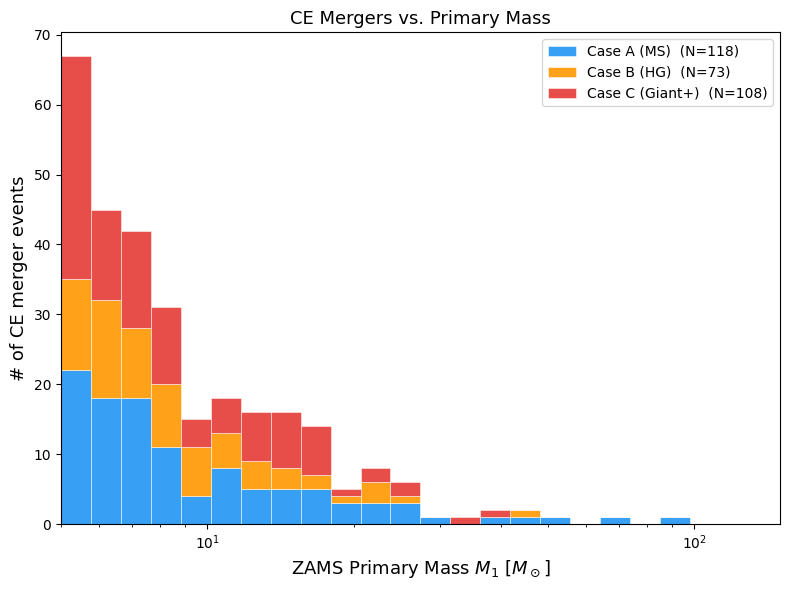

In [13]:
case_colors  = {'Case A (MS)': '#2196F3', 'Case B (HG)': '#FF9800', 'Case C (Giant+)': '#E53935'}
case_masks   = {
    'Case A (MS)': ce_mergers['case_A'],
    'Case B (HG)': ce_mergers['case_B'],
    'Case C (Giant+)': ce_mergers['case_C'],
}

# -- Plotting the distribution of ZAMS primary masses for CE mergers by MT case --
# Create log bins from 5 to 150 Msun
m1_bins = np.logspace(np.log10(5), np.log10(150), 25)
bin_centers = 0.5 * (m1_bins[:-1] + m1_bins[1:])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bottoms = np.zeros(len(m1_bins) - 1)
for label, mask in case_masks.items():
    counts, _ = np.histogram(ce_mergers.loc[mask, 'Mass@ZAMS(1)'], bins=m1_bins)
    ax.bar(bin_centers, counts, width=np.diff(m1_bins),
           bottom=bottoms, color=case_colors[label],
           label=f'{label}  (N={mask.sum():,})',
           edgecolor='white', linewidth=0.4, alpha=0.9)
    bottoms += counts

ax.set_xscale('log')
ax.set_xlabel(r'ZAMS Primary Mass $M_{1}$ [$M_\odot$]', fontsize=13)
ax.set_ylabel('# of CE merger events', fontsize=13)
ax.set_title('CE Mergers vs. Primary Mass', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([5, 150])

plt.tight_layout()
plt.show()

Tristan: We can conclude from this that CE mergers are dominated by lower-mass primaries, and most come from evolved donors (Case C). Further, CE during HG looks to be least common. For super high ZAMS, CE mergers come primarily from Case A.

How about orbital period?

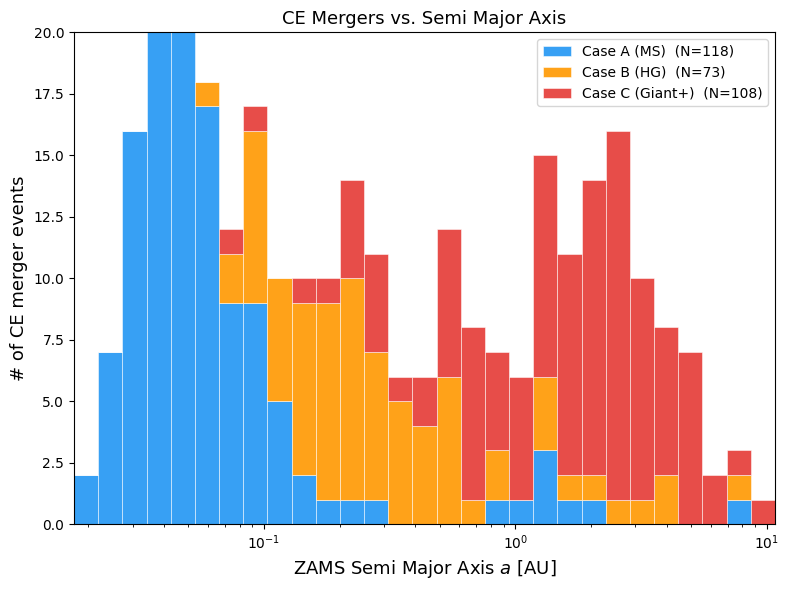

In [14]:
case_colors  = {'Case A (MS)': '#2196F3', 'Case B (HG)': '#FF9800', 'Case C (Giant+)': '#E53935'}
case_masks   = {
    'Case A (MS)': ce_mergers['case_A'],
    'Case B (HG)': ce_mergers['case_B'],
    'Case C (Giant+)': ce_mergers['case_C'],
}

# -- Plotting the distribution of semi-major axes for CE mergers by MT case --
# Create log bins from 5 to 150 Msun
a_data = ce_mergers['SemiMajorAxis@ZAMS']
a_bins = np.logspace(np.log10(a_data.min()), np.log10(a_data.max()), 30)
bin_centers = 0.5 * (a_bins[:-1] + a_bins[1:])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bottoms = np.zeros(len(a_bins) - 1)
for label, mask in case_masks.items():
    counts, _ = np.histogram(ce_mergers.loc[mask, 'SemiMajorAxis@ZAMS'], bins=a_bins)
    ax.bar(bin_centers, counts, width=np.diff(a_bins),
           bottom=bottoms, color=case_colors[label],
           label=f'{label}  (N={mask.sum():,})',
           edgecolor='white', linewidth=0.4, alpha=0.9)
    bottoms += counts

ax.set_xscale('log')
ax.set_xlabel(r'ZAMS Semi Major Axis $a$ [AU]', fontsize=13)
ax.set_ylabel('# of CE merger events', fontsize=13)
ax.set_title('CE Mergers vs. Semi Major Axis', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(a_data.min(), a_data.max())

plt.tight_layout()
plt.show()

Think about what you see in the plots. Why does the MT case contribution change over semi-major axis?

Tristan: From this plot, it seems that the more evolved the donor, the more spread out the binary can be (i.e., larger orbital semi-major axis) while still undergoing a CE merger. Different evolutionary stages have different stellar radii---in particular, MS stars (blue) have a small radius and hence must be very small to fill their Roche lobe.

The changing MT case contribution with semi-major axis reflects the fact that larger separations require larger stellar radii to trigger interaction, so more evolved stars dominate at wider orbits. Whether a star initiates mass transfer depends on whether its radius becomes comparable to its Roche lobe radius, which itself scales with the orbital separation. In binaries with a small semi-major axis (i.e., the two stars are relatively close together), even relatively small main-sequence stars can fill their Roche lobes, which is why Case A dominates on the left in the plot. As separation increases, main-sequence stars are too small to interact; only stars that have evolved and expanded (first in the Hertzsprung gap (Case B) then into giants (Case C)) can reach their Roche lobes. Thus, systems with a larger semi-major axis (i.e., the two stars are relatively farther apart) dominate on the right in the plot.